<a href="https://colab.research.google.com/github/Ajitgupta31/Machine_Learning/blob/main/XGboost_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

XGBoost Accuracy: 0.43986254295532645

Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.97      0.61       258
           1       0.42      0.02      0.03       324

    accuracy                           0.44       582
   macro avg       0.43      0.49      0.32       582
weighted avg       0.43      0.44      0.29       582



/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


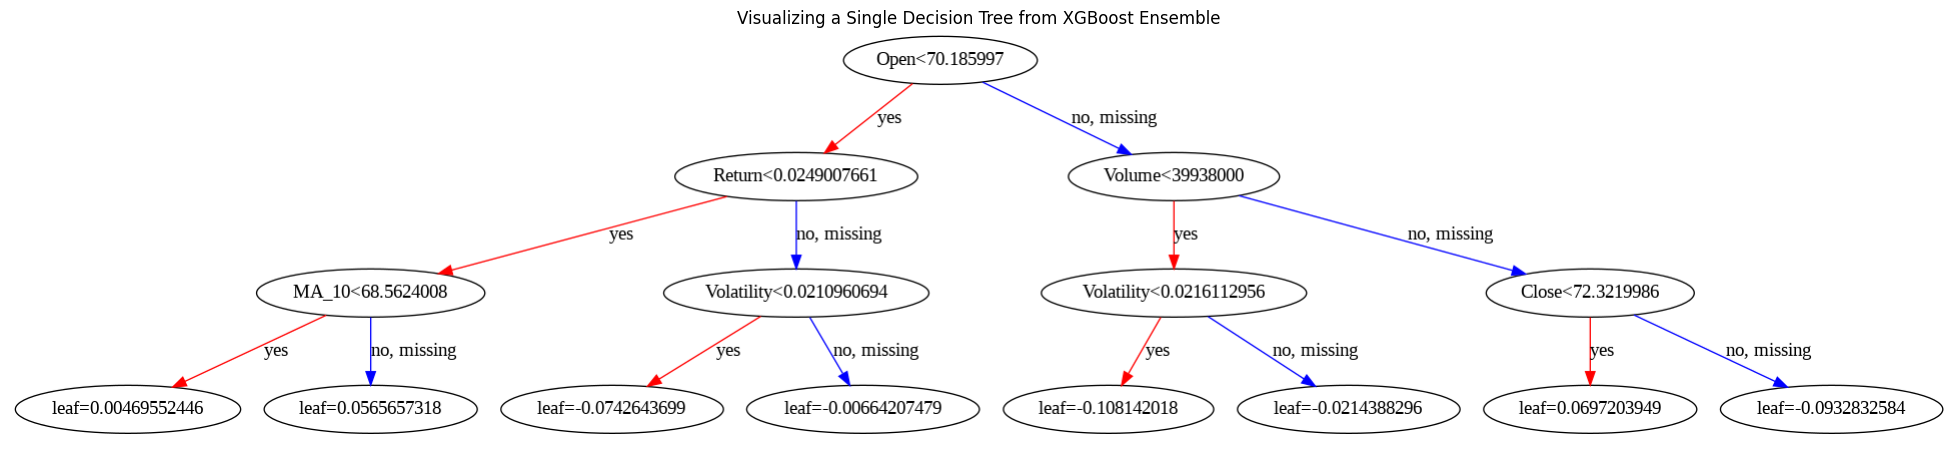

Baseline Single Decision Tree Accuracy: 0.5292096219931272


In [5]:

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

# ---------------------------------------------------------
# 1. Load and Prepare Data
# ---------------------------------------------------------
df = pd.read_csv('/content/drive/MyDrive/Tesla')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

# ---------------------------------------------------------
# 2. Feature Engineering
# ---------------------------------------------------------
# Create simple technical indicators
df['Return'] = df['Close'].pct_change()
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['Volatility'] = df['Return'].rolling(window=10).std()

# Target Variable: 1 (Buy) if tomorrow's close > today's close, else 0 (Sell)
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

# Drop rows with NaN values created by rolling/shifting
df.dropna(inplace=True)

# Define our features (X) and target label (y)
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'MA_10', 'MA_50', 'Volatility']
X = df[features]
y = df['Target']

# ---------------------------------------------------------
# 3. Time-Series Train-Test Split
# ---------------------------------------------------------
# Use 80% of data for training, 20% for testing
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ---------------------------------------------------------
# 4. Train the XGBoost Model
# ---------------------------------------------------------
xgb_model = xgb.XGBClassifier(
    n_estimators=100,      # Number of decision trees
    max_depth=3,           # Maximum depth of each tree
    learning_rate=0.1,     # Step size shrinkage
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---------------------------------------------------------
# 5. Approach 1: Visualize a single Decision Tree from XGBoost
# ---------------------------------------------------------
# This plots the very first decision tree (num_trees=0) in the XGBoost ensemble.
plt.figure(figsize=(25, 10))
xgb.plot_tree(xgb_model, num_trees=0, ax=plt.gca())
plt.title("Visualizing a Single Decision Tree from XGBoost Ensemble")
plt.show()

# ---------------------------------------------------------
# 6. Approach 2: Train a Baseline Decision Tree for Comparison (Optional)
# ---------------------------------------------------------
# This provides a great talking point for a project report:
# Comparing a single basic tree vs. an advanced ensemble.
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Baseline Single Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Loading data...
Engineering features...

Training Random Forest...
Random Forest Accuracy: 0.4467
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.99      0.61       258
           1       0.67      0.01      0.02       324

    accuracy                           0.45       582
   macro avg       0.56      0.50      0.32       582
weighted avg       0.57      0.45      0.29       582


Training XGBoost...
XGBoost Accuracy: 0.4399
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.97      0.61       258
           1       0.42      0.02      0.03       324

    accuracy                           0.44       582
   macro avg       0.43      0.49      0.32       582
weighted avg       0.43      0.44      0.29       582



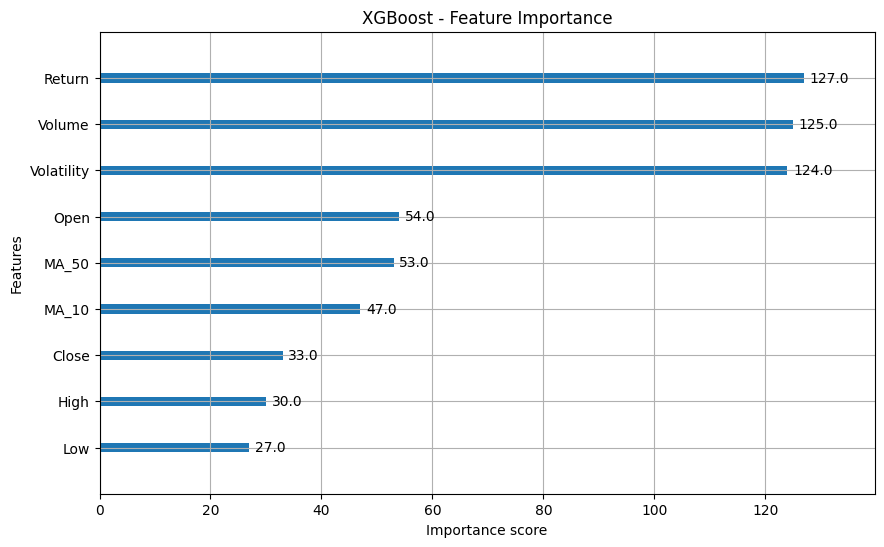

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

# 1. Load Data
print("Loading data...")
df = pd.read_csv('/content/drive/MyDrive/Tesla')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

# 2. Feature Engineering
print("Engineering features...")
df['Return'] = df['Close'].pct_change()
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['Volatility'] = df['Return'].rolling(window=10).std()

# Target: 1 (Buy) if tomorrow's close > today's close, else 0 (Sell)
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

# Drop NaN values generated by rolling/shift operations
df.dropna(inplace=True)

# Define Features (X) and Target (y)
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'MA_10', 'MA_50', 'Volatility']
X = df[features]
y = df['Target']

# 3. Train-Test Split (Chronological split for time series)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ==========================================
# 4. Model 1: Random Forest (Baseline)
# ==========================================
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Random Forest Predictions
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("Random Forest Classification Report:\n", classification_report(y_test, rf_pred))

# ==========================================
# 5. Model 2: XGBoost (Advanced)
# ==========================================
print("\nTraining XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# XGBoost Predictions
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print("XGBoost Classification Report:\n", classification_report(y_test, xgb_pred))

# ==========================================
# 6. Interpretability: Feature Importance
# ==========================================
# Plotting Feature Importance for XGBoost
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, ax=plt.gca(), title="XGBoost - Feature Importance")
plt.show()
